# Exploratory Data Analysis: How Do Data Centers Impact Local Power Infrastructure?

This notebook combines the **FracTracker data-center database** with EIA electricity data on:

- number of electricity customers,
- power-plant generation, and
- retail electricity prices.

## Research question

> **How do data centers impact local power infrastructure?**

The available electricity indicators are primarily reported at the **state level**, while the data centers are individual facilities. Therefore, this notebook evaluates whether states with larger data-center footprints also show different patterns in electricity generation, customer growth, and electricity prices. These relationships are **descriptive associations**, not proof that data centers caused the observed changes.

## Main analytical strategy

1. Clean and summarize the data-center inventory.
2. Build state-level measures of data-center concentration.
3. Reshape annual, quarterly, and monthly EIA files into tidy form.
4. Compare data-center concentration with generation, customer counts, and prices.
5. Examine recent changes and time trends in high-data-center states.
6. Identify limitations and next steps needed for a stronger infrastructure-impact study.

In [1]:
import os
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# Use a clean, readable plotting default without requiring optional libraries.
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

## 1. Load the datasets

In [2]:
DATA_DIR = Path("Data")

files = {
    "data_centers": "Data_Centers_Database - FracTracker Data Centers.csv",
    "customers_annual": "ELEC.CUSTOMERS.A.csv",
    "customers_monthly": "ELEC.CUSTOMERS.M.csv",
    "customers_quarterly": "ELEC.CUSTOMERS.Q.csv",
    "generation_annual": "ELEC.PLANT.GEN.A.csv",
    "generation_monthly": "ELEC.PLANT.GEN.M.csv",
    "generation_quarterly": "ELEC.PLANT.GEN.Q.csv",
    "price_annual": "ELEC.PRICE.A.csv",
    "price_monthly": "ELEC.PRICE.M.csv",
    "price_quarterly": "ELEC.PRICE.Q.csv",
}

paths = {name: DATA_DIR / filename for name, filename in files.items()}
missing = [str(path) for path in paths.values() if not path.exists()]
if missing:
    raise FileNotFoundError(f"Missing files: {missing}")

dc = pd.read_csv(paths["data_centers"])
customers_a = pd.read_csv(paths["customers_annual"])
customers_m = pd.read_csv(paths["customers_monthly"])
customers_q = pd.read_csv(paths["customers_quarterly"])
generation_a = pd.read_csv(paths["generation_annual"])
generation_m = pd.read_csv(paths["generation_monthly"])
generation_q = pd.read_csv(paths["generation_quarterly"])
price_a = pd.read_csv(paths["price_annual"])
price_m = pd.read_csv(paths["price_monthly"])
price_q = pd.read_csv(paths["price_quarterly"])

summary = pd.DataFrame({
    "dataset": list(files.keys()),
    "rows": [dc.shape[0], customers_a.shape[0], customers_m.shape[0], customers_q.shape[0],
             generation_a.shape[0], generation_m.shape[0], generation_q.shape[0],
             price_a.shape[0], price_m.shape[0], price_q.shape[0]],
    "columns": [dc.shape[1], customers_a.shape[1], customers_m.shape[1], customers_q.shape[1],
                generation_a.shape[1], generation_m.shape[1], generation_q.shape[1],
                price_a.shape[1], price_m.shape[1], price_q.shape[1]]
})
summary

,dataset,rows,columns
0,data_centers,1592,44
1,customers_annual,289,26
2,customers_monthly,289,227
3,customers_quarterly,289,81
4,generation_annual,57485,33
5,generation_monthly,57550,311
6,generation_quarterly,57540,109
7,price_annual,352,33
8,price_monthly,352,311
9,price_quarterly,352,109


## 2. Initial data quality checks

In [3]:
def quality_report(df, name):
    return pd.Series({
        "dataset": name,
        "rows": len(df),
        "columns": df.shape[1],
        "duplicate_rows": df.duplicated().sum(),
        "missing_cells_pct": 100 * df.isna().sum().sum() / df.size,
    })

pd.DataFrame([
    quality_report(dc, "data_centers"),
    quality_report(customers_a, "customers_annual"),
    quality_report(generation_a, "generation_annual"),
    quality_report(price_a, "price_annual"),
])

,dataset,rows,columns,duplicate_rows,missing_cells_pct
0,data_centers,1592,44,0,54.61
1,customers_annual,289,26,0,0.65
2,generation_annual,57485,33,0,41.86
3,price_annual,352,33,0,0.51


In [4]:
# Data-center fields with the highest missingness
missing_dc = (dc.isna().mean() * 100).sort_values(ascending=False).to_frame("missing_pct")
missing_dc.head(20)

,missing_pct
tenant,99.94
nda,99.31
number_of_generators,99.18
info_source_8,99.12
info_source_7,98.43
dedicated_power_plant,97.99
community_group_website_2,97.93
info_source_6,97.30
cooling_source,96.92
cooling_type,96.48


### Important measurement caveats

- The `mw` field is text and contains missing or inconsistently formatted values.
- Many proposed facilities have uncertain or future demand.
- State-level EIA measures cannot reveal substation congestion, transmission upgrades, outages, or county-level effects.
- The generation data contains plant-level series. It must be aggregated to the state level before comparison.
- 2026 observations are incomplete, so **2025 is used as the latest full annual comparison year**.

## 3. Clean the data-center data

In [5]:
# Standardize text and state codes.
dc.columns = dc.columns.str.strip().str.lower()
dc["state"] = dc["state"].astype("string").str.strip().str.upper()
dc["status"] = dc["status"].astype("string").str.strip()
dc["facility_name"] = dc["facility_name"].astype("string").str.strip()

# Extract the first numeric value from MW descriptions such as "100 MW", "1,200", or "~50".
def parse_numeric(value):
    if pd.isna(value):
        return np.nan
    text = str(value).replace(",", "")
    match = re.search(r"[-+]?\d*\.?\d+", text)
    return float(match.group()) if match else np.nan

dc["mw_numeric"] = dc["mw"].apply(parse_numeric)
dc["facility_size_sqft_numeric"] = dc["facility_size_sqft"].apply(parse_numeric)
dc["number_of_generators_numeric"] = dc["number_of_generators"].apply(parse_numeric)

# Broad status categories used throughout the notebook.
operating_statuses = {"Operating", "Expanding"}
pipeline_statuses = {"Proposed", "Approved/Permitted/Under construction", "Expanding"}

dc["is_operating"] = dc["status"].isin(operating_statuses)
dc["is_pipeline"] = dc["status"].isin(pipeline_statuses)
dc["is_cancelled"] = dc["status"].eq("Cancelled")

pd.DataFrame({
    "original_mw": dc["mw"].head(15),
    "parsed_mw": dc["mw_numeric"].head(15)
})

,original_mw,parsed_mw
0,10,10.00
1,3000,"3,000.00"
2,120,120.00
3,500,500.00
4,1200,"1,200.00"
5,300,300.00
6,NaN,NaN
7,NaN,NaN
8,500,500.00
9,NaN,NaN


In [6]:
status_summary = dc["status"].value_counts(dropna=False).rename_axis("status").reset_index(name="facilities")
status_summary

,status,facilities
0,Proposed,725
1,Operating,531
2,Approved/Permitted/Under construction,159
3,Cancelled,61
4,Expanding,59
5,Suspended,57


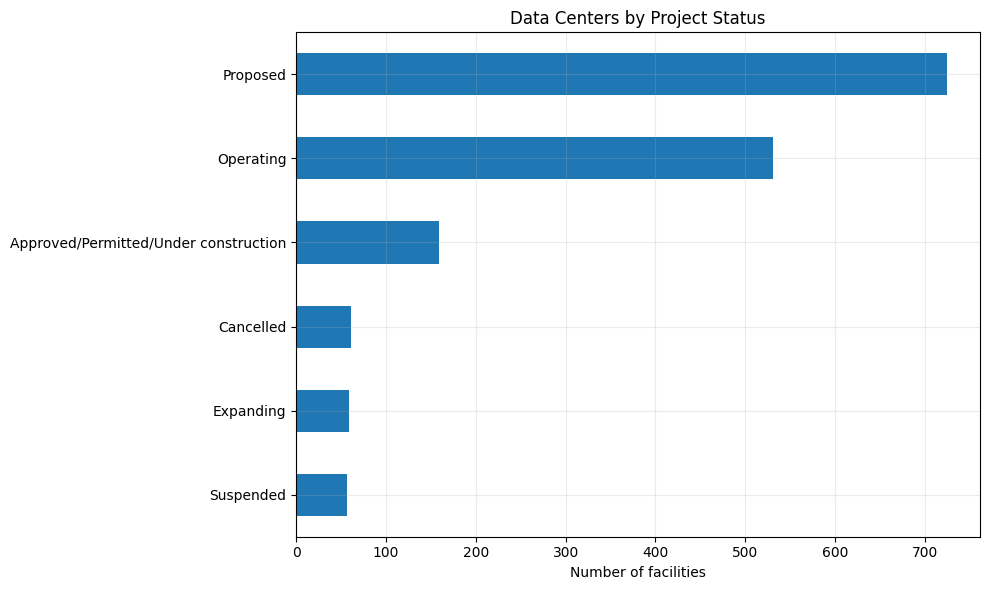

In [7]:
ax = status_summary.set_index("status")["facilities"].sort_values().plot(kind="barh")
ax.set_title("Data Centers by Project Status")
ax.set_xlabel("Number of facilities")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

In [8]:
# How complete is the key MW measure?
mw_completeness = pd.DataFrame({
    "group": ["All facilities", "Operating/expanding", "Pipeline"],
    "facilities": [len(dc), dc["is_operating"].sum(), dc["is_pipeline"].sum()],
    "facilities_with_mw": [dc["mw_numeric"].notna().sum(),
                           dc.loc[dc["is_operating"], "mw_numeric"].notna().sum(),
                           dc.loc[dc["is_pipeline"], "mw_numeric"].notna().sum()]
})
mw_completeness["mw_coverage_pct"] = 100 * mw_completeness["facilities_with_mw"] / mw_completeness["facilities"]
mw_completeness

,group,facilities,facilities_with_mw,mw_coverage_pct
0,All facilities,1592,595,37.37
1,Operating/expanding,590,220,37.29
2,Pipeline,943,355,37.65


## 4. Geographic concentration of data centers

In [9]:
state_dc = (
    dc.groupby("state", dropna=False)
      .agg(
          total_facilities=("facility_name", "count"),
          operating_facilities=("is_operating", "sum"),
          pipeline_facilities=("is_pipeline", "sum"),
          cancelled_facilities=("is_cancelled", "sum"),
          reported_total_mw=("mw_numeric", "sum"),
          operating_reported_mw=("mw_numeric", lambda s: s[dc.loc[s.index, "is_operating"]].sum()),
          pipeline_reported_mw=("mw_numeric", lambda s: s[dc.loc[s.index, "is_pipeline"]].sum()),
          mw_reporting_rate=("mw_numeric", lambda s: s.notna().mean()),
      )
      .reset_index()
)

state_dc = state_dc[state_dc["state"].str.fullmatch(r"[A-Z]{2}", na=False)]
state_dc.sort_values("total_facilities", ascending=False).head(15)

,state,total_facilities,operating_facilities,pipeline_facilities,cancelled_facilities,reported_total_mw,operating_reported_mw,pipeline_reported_mw,mw_reporting_rate
43,VA,459,215,263,7,"18,273.70","1,525.70","10,971.00",0.09
41,TX,199,66,137,1,"57,211.95","5,612.95","52,791.00",0.48
9,GA,178,87,85,4,"16,725.10","3,540.10","11,307.00",0.53
37,PA,103,45,51,4,"19,109.10",437.10,"17,284.00",0.39
34,OH,63,17,43,2,"17,381.60","1,269.60","15,635.00",0.54
14,IN,41,7,24,3,"12,241.40","2,204.40","9,733.00",0.29
13,IL,36,5,27,4,"8,654.35",90.35,"8,528.00",0.54
33,NY,36,16,16,2,"5,866.42",824.42,"3,642.00",0.86
23,MO,33,5,25,2,"3,680.00",0.00,"3,680.00",0.24
3,AZ,30,10,20,1,"7,014.00",568.00,"6,446.00",0.57


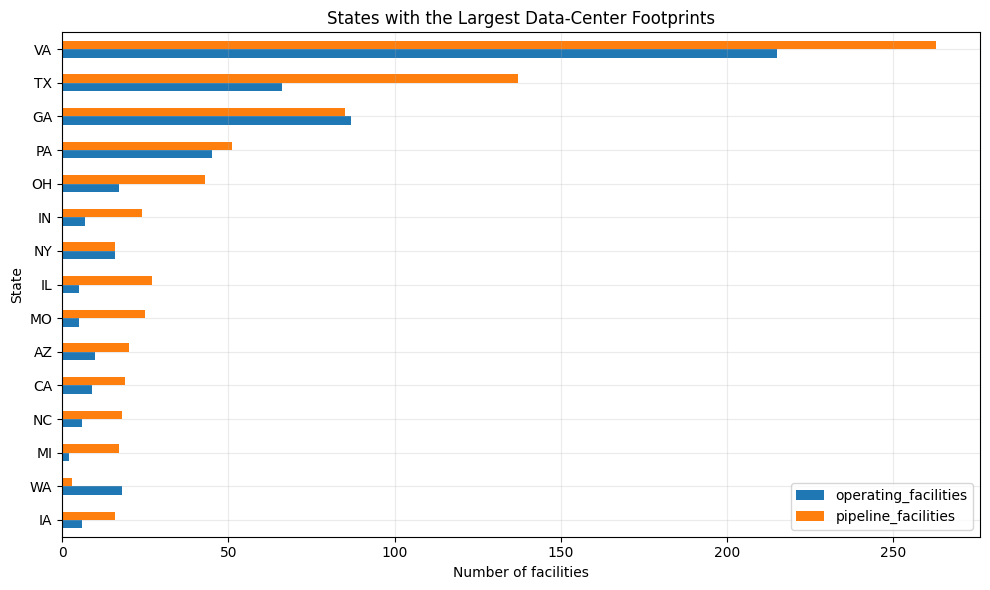

In [10]:
top_states = state_dc.nlargest(15, "total_facilities").sort_values("total_facilities")
ax = top_states.set_index("state")[["operating_facilities", "pipeline_facilities"]].plot(kind="barh")
ax.set_title("States with the Largest Data-Center Footprints")
ax.set_xlabel("Number of facilities")
ax.set_ylabel("State")
plt.tight_layout()
plt.show()

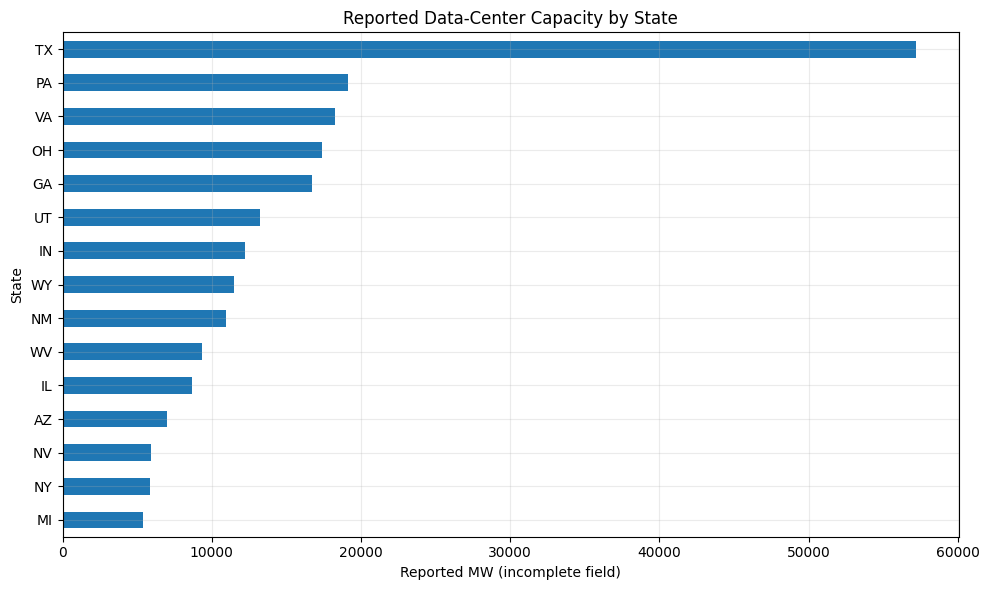

In [11]:
# MW totals can be informative, but they are based only on facilities with reported MW values.
top_mw = state_dc.nlargest(15, "reported_total_mw").sort_values("reported_total_mw")
ax = top_mw.set_index("state")["reported_total_mw"].plot(kind="barh")
ax.set_title("Reported Data-Center Capacity by State")
ax.set_xlabel("Reported MW (incomplete field)")
ax.set_ylabel("State")
plt.tight_layout()
plt.show()

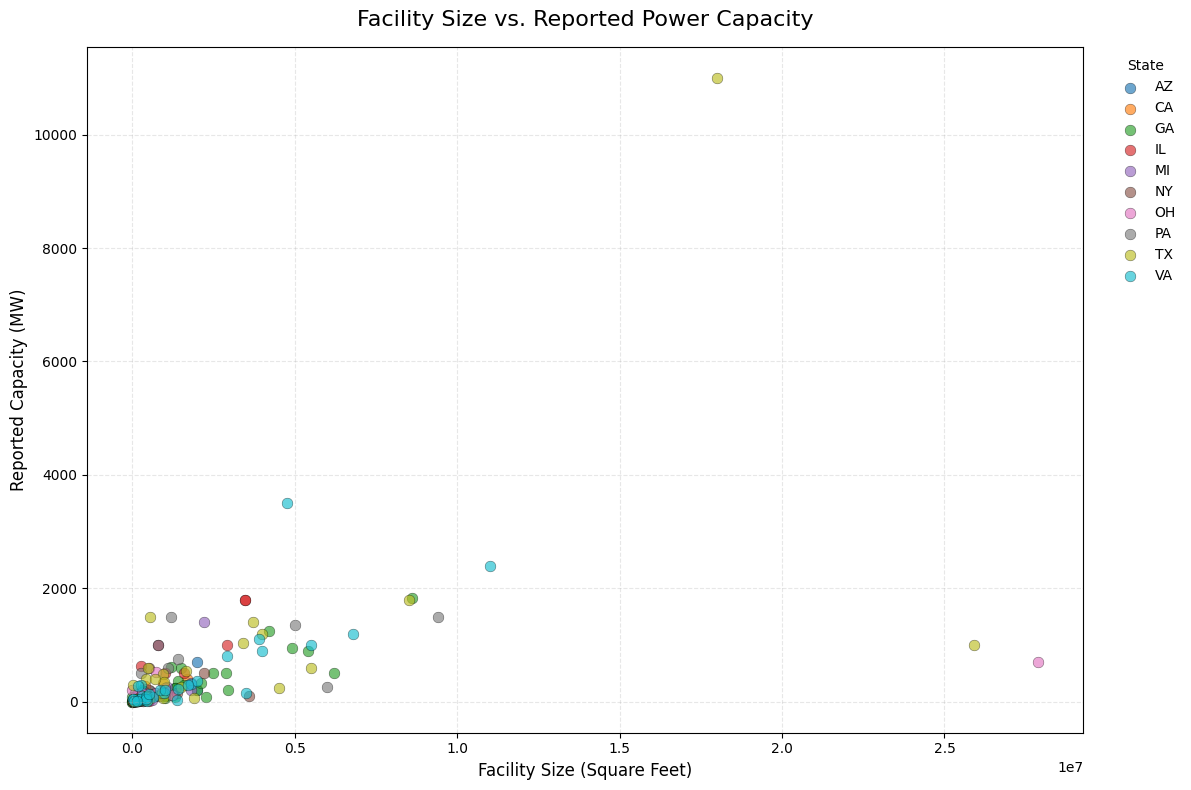

In [12]:
plot_data = dc.dropna(
    subset=["mw_numeric", "facility_size_sqft_numeric", "state"]
).copy()

# Only show the 10 states with the most facilities
top_states = plot_data["state"].value_counts().head(10).index
plot_data = plot_data[plot_data["state"].isin(top_states)]

fig, ax = plt.subplots(figsize=(12, 8))

states = sorted(plot_data["state"].unique())
colors = plt.cm.tab10.colors

for color, state in zip(colors, states):
    subset = plot_data[plot_data["state"] == state]
    ax.scatter(
        subset["facility_size_sqft_numeric"],
        subset["mw_numeric"],
        s=60,
        alpha=0.65,
        color=color,
        edgecolors="black",
        linewidths=0.3,
        label=state,
    )


ax.set_title("Facility Size vs. Reported Power Capacity", fontsize=16, pad=15)
ax.set_xlabel("Facility Size (Square Feet)", fontsize=12)
ax.set_ylabel("Reported Capacity (MW)", fontsize=12)

ax.grid(True, which="both", linestyle="--", alpha=0.3)

ax.legend(
    title="State",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False,
)

plt.tight_layout()
plt.show()

## 5. Reshape EIA electricity data

In [13]:
META_COLS = ["series_id", "name", "geography", "iso3166", "sector", "units"]

def state_from_iso(series):
    return series.astype("string").str.extract(r"USA-([A-Z]{2})", expand=False)

def annual_to_long(df, value_name):
    df = df.drop(columns=[c for c in df.columns if c.lower().startswith("unnamed")], errors="ignore").copy()
    year_cols = [c for c in df.columns if re.fullmatch(r"\d{4}", str(c))]
    out = df.melt(id_vars=[c for c in META_COLS if c in df.columns], value_vars=year_cols,
                  var_name="year", value_name=value_name)
    out["year"] = pd.to_numeric(out["year"], errors="coerce").astype("Int64")
    out[value_name] = pd.to_numeric(out[value_name], errors="coerce")
    out["state"] = state_from_iso(out["iso3166"])
    return out

def monthly_to_long(df, value_name):
    df = df.drop(columns=[c for c in df.columns if c.lower().startswith("unnamed")], errors="ignore").copy()
    month_cols = [c for c in df.columns if re.fullmatch(r"\d{6}", str(c))]
    out = df.melt(id_vars=[c for c in META_COLS if c in df.columns], value_vars=month_cols,
                  var_name="period", value_name=value_name)
    out["date"] = pd.to_datetime(out["period"], format="%Y%m", errors="coerce")
    out[value_name] = pd.to_numeric(out[value_name], errors="coerce")
    out["state"] = state_from_iso(out["iso3166"])
    return out

def quarterly_to_long(df, value_name):
    df = df.drop(columns=[c for c in df.columns if c.lower().startswith("unnamed")], errors="ignore").copy()
    quarter_cols = [c for c in df.columns if re.fullmatch(r"\d{4}Q[1-4]", str(c))]
    out = df.melt(id_vars=[c for c in META_COLS if c in df.columns], value_vars=quarter_cols,
                  var_name="period", value_name=value_name)
    out["date"] = pd.PeriodIndex(out["period"], freq="Q").to_timestamp(how="end").normalize()
    out[value_name] = pd.to_numeric(out[value_name], errors="coerce")
    out["state"] = state_from_iso(out["iso3166"])
    return out

customers_a_long = annual_to_long(customers_a, "customers")
price_a_long = annual_to_long(price_a, "price_cents_kwh")
generation_a_long = annual_to_long(generation_a, "generation_mwh")

customers_m_long = monthly_to_long(customers_m, "customers")
price_m_long = monthly_to_long(price_m, "price_cents_kwh")

customers_q_long = quarterly_to_long(customers_q, "customers")
price_q_long = quarterly_to_long(price_q, "price_cents_kwh")

customers_a_long.head()

,series_id,name,geography,iso3166,sector,units,year,customers,state
0,ELEC.CUSTOMERS.MT-ALL.A,Number of customer accounts : Montana : all se...,USA-MT,USA-MT,All,number of customers,2008,"566,847.58",MT
1,ELEC.CUSTOMERS.MT-COM.A,Number of customer accounts : Montana : commer...,USA-MT,USA-MT,Commercial,number of customers,2008,"100,372.33",MT
2,ELEC.CUSTOMERS.MT-IND.A,Number of customer accounts : Montana : indust...,USA-MT,USA-MT,Industrial,number of customers,2008,"4,877.25",MT
3,ELEC.CUSTOMERS.WI-IND.A,Number of customer accounts : Wisconsin : indu...,USA-WI,USA-WI,Industrial,number of customers,2008,"4,683.08",WI
4,ELEC.CUSTOMERS.WI-RES.A,Number of customer accounts : Wisconsin : resi...,USA-WI,USA-WI,Residential,number of customers,2008,"2,579,774.42",WI


### State aggregation rules

- **Customers:** use the EIA `All` sector to avoid double counting.
- **Prices:** examine `All`, `Commercial`, and `Industrial` rates. Industrial/commercial rates are especially relevant because data centers are large non-residential loads.
- **Generation:** sum all plant-level net-generation series within each state and year. Each input series represents all fuels and all prime movers for a plant.

In [14]:
state_customers = (
    customers_a_long.query("sector == 'All'")
    .groupby(["state", "year"], as_index=False)["customers"].sum(min_count=1)
)

state_prices = (
    price_a_long[price_a_long["sector"].isin(["All", "Commercial", "Industrial", "Residential"])]
    .groupby(["state", "year", "sector"], as_index=False)["price_cents_kwh"].mean()
)

state_generation = (
    generation_a_long.groupby(["state", "year"], as_index=False)["generation_mwh"].sum(min_count=1)
)

print("State-customer rows:", len(state_customers))
print("State-price rows:", len(state_prices))
print("State-generation rows:", len(state_generation))

State-customer rows: 969
State-price rows: 5304
State-generation rows: 1326


## 6. Build a state-level analytical table

In [15]:
LATEST_FULL_YEAR = 2025
BASE_YEAR = 2015

latest_customers = state_customers.query("year == @LATEST_FULL_YEAR").drop(columns="year")
latest_generation = state_generation.query("year == @LATEST_FULL_YEAR").drop(columns="year")
latest_prices = (
    state_prices.query("year == @LATEST_FULL_YEAR")
    .pivot(index="state", columns="sector", values="price_cents_kwh")
    .add_prefix("price_")
    .reset_index()
)

# Calculate changes from 2015 to 2025.
def growth_table(df, value_col, prefix):
    wide = df[df["year"].isin([BASE_YEAR, LATEST_FULL_YEAR])].pivot(index="state", columns="year", values=value_col)
    wide[f"{prefix}_pct_change"] = 100 * (wide[LATEST_FULL_YEAR] - wide[BASE_YEAR]) / wide[BASE_YEAR].replace(0, np.nan)
    return wide[[f"{prefix}_pct_change"]].reset_index()

customer_growth = growth_table(state_customers, "customers", "customers_2015_2025")
generation_growth = growth_table(state_generation, "generation_mwh", "generation_2015_2025")

price_growth_parts = []
for sector in ["All", "Commercial", "Industrial", "Residential"]:
    temp = growth_table(state_prices[state_prices["sector"] == sector], "price_cents_kwh", f"price_{sector.lower()}_2015_2025")
    price_growth_parts.append(temp)

state_analysis = state_dc.merge(latest_customers, on="state", how="left")
state_analysis = state_analysis.merge(latest_generation, on="state", how="left")
state_analysis = state_analysis.merge(latest_prices, on="state", how="left")
state_analysis = state_analysis.merge(customer_growth, on="state", how="left")
state_analysis = state_analysis.merge(generation_growth, on="state", how="left")
for part in price_growth_parts:
    state_analysis = state_analysis.merge(part, on="state", how="left")

state_analysis["generation_mwh_per_customer"] = state_analysis["generation_mwh"] / state_analysis["customers"]
state_analysis["facilities_per_million_customers"] = state_analysis["total_facilities"] / state_analysis["customers"] * 1_000_000
state_analysis["operating_facilities_per_million_customers"] = state_analysis["operating_facilities"] / state_analysis["customers"] * 1_000_000

state_analysis.sort_values("total_facilities", ascending=False).head(15)

,state,total_facilities,operating_facilities,pipeline_facilities,cancelled_facilities,reported_total_mw,operating_reported_mw,pipeline_reported_mw,mw_reporting_rate,customers,generation_mwh,price_All,price_Commercial,price_Industrial,price_Residential,customers_2015_2025_pct_change,generation_2015_2025_pct_change,price_all_2015_2025_pct_change,price_commercial_2015_2025_pct_change,price_industrial_2015_2025_pct_change,price_residential_2015_2025_pct_change,generation_mwh_per_customer,facilities_per_million_customers,operating_facilities_per_million_customers
43,VA,459,215,263,7,"18,273.70","1,525.70","10,971.00",0.09,"4,139,275.50","287,160,429.66",11.41,9.55,9.45,15.28,9.97,39.46,22.56,16.32,35.97,34.39,69.37,110.89,51.94
41,TX,199,66,137,1,"57,211.95","5,612.95","52,791.00",0.48,"14,673,329.00","1,513,698,055.90",10.18,8.64,6.55,15.47,23.83,19.21,17.01,6.01,17.17,33.82,103.16,13.56,4.50
9,GA,178,87,85,4,"16,725.10","3,540.10","11,307.00",0.53,"5,490,840.17","400,564,761.92",12.03,11.50,7.81,14.73,15.04,12.81,25.05,16.28,33.05,27.64,72.95,32.42,15.84
37,PA,103,45,51,4,"19,109.10",437.10,"17,284.00",0.39,"6,301,845.83","695,082,989.10",14.11,12.44,9.36,19.30,4.70,12.61,36.86,29.58,30.00,41.50,110.30,16.34,7.14
34,OH,63,17,43,2,"17,381.60","1,269.60","15,635.00",0.54,"5,735,231.17","398,809,294.93",12.43,11.60,8.52,16.96,3.66,10.12,24.55,15.19,21.37,32.50,69.54,10.98,2.96
14,IN,41,7,24,3,"12,241.40","2,204.40","9,733.00",0.29,"3,398,459.25","289,686,406.52",12.57,13.88,8.89,16.23,7.09,-5.29,39.82,41.92,29.59,40.28,85.24,12.06,2.06
13,IL,36,5,27,4,"8,654.35",90.35,"8,528.00",0.54,"6,033,458.00","516,026,574.78",13.74,13.07,10.14,17.69,4.35,-11.09,46.17,44.90,52.02,41.52,85.53,5.97,0.83
33,NY,36,16,16,2,"5,866.42",824.42,"3,642.00",0.86,"8,643,566.50","323,609,085.67",21.62,21.07,9.55,26.39,6.16,-19.48,41.49,37.62,51.35,42.34,37.44,4.16,1.85
23,MO,33,5,25,2,"3,680.00",0.00,"3,680.00",0.24,"3,288,848.67","199,443,916.90",11.57,10.63,8.38,13.49,5.47,-20.51,22.56,16.05,30.12,20.34,60.64,10.03,1.52
3,AZ,30,10,20,1,"7,014.00",568.00,"6,446.00",0.57,"3,519,509.75","332,616,913.62",12.97,12.47,8.10,15.32,16.86,2.39,25.44,20.02,29.39,26.30,94.51,8.52,2.84


## 7. Cross-sectional relationships in 2025

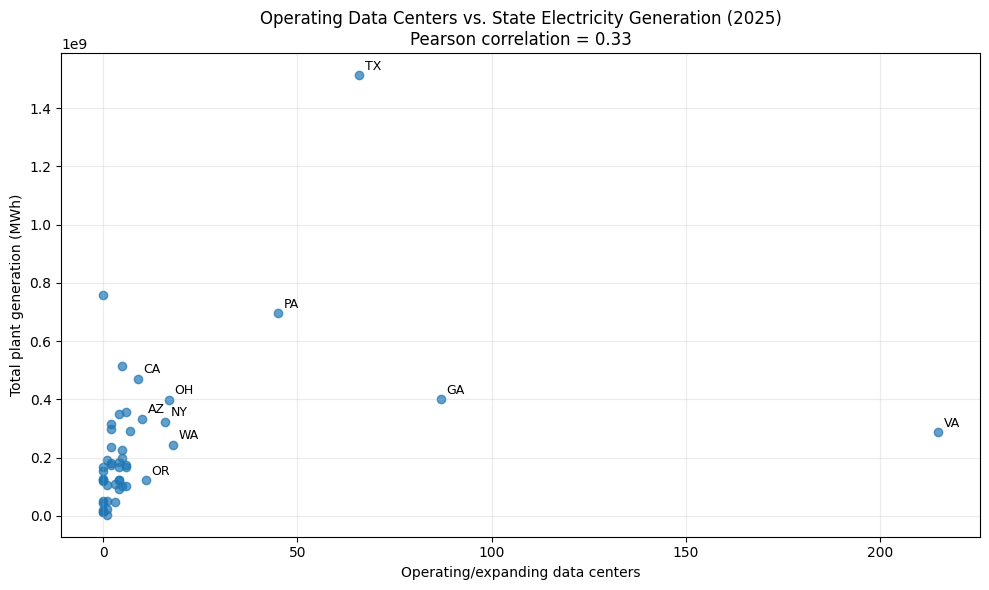

In [16]:
def scatter_with_labels(data, x, y, title, xlabel, ylabel, label_n=10):
    plot_data = data[["state", x, y]].replace([np.inf, -np.inf], np.nan).dropna()
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.scatter(plot_data[x], plot_data[y], alpha=0.7)
    labels = plot_data.nlargest(label_n, x)
    for _, row in labels.iterrows():
        ax.annotate(row["state"], (row[x], row[y]), xytext=(4, 4), textcoords="offset points", fontsize=9)
    corr = plot_data[[x, y]].corr().iloc[0, 1]
    ax.set_title(f"{title}\nPearson correlation = {corr:.2f}")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    plt.tight_layout()
    plt.show()
    return corr

corr_generation = scatter_with_labels(
    state_analysis, "operating_facilities", "generation_mwh",
    "Operating Data Centers vs. State Electricity Generation (2025)",
    "Operating/expanding data centers", "Total plant generation (MWh)"
)

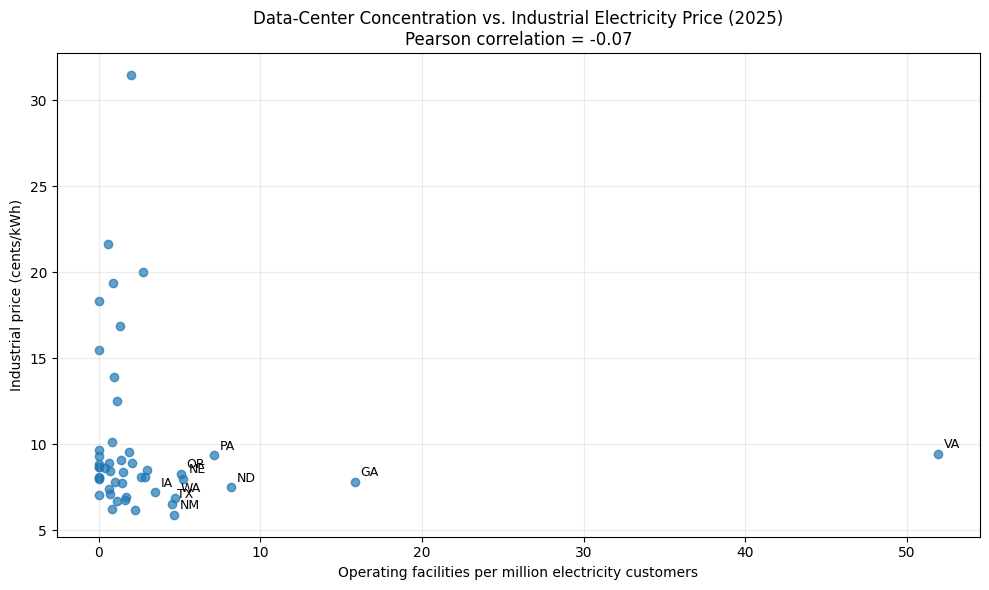

In [17]:
corr_industrial_price = scatter_with_labels(
    state_analysis, "operating_facilities_per_million_customers", "price_Industrial",
    "Data-Center Concentration vs. Industrial Electricity Price (2025)",
    "Operating facilities per million electricity customers", "Industrial price (cents/kWh)"
)

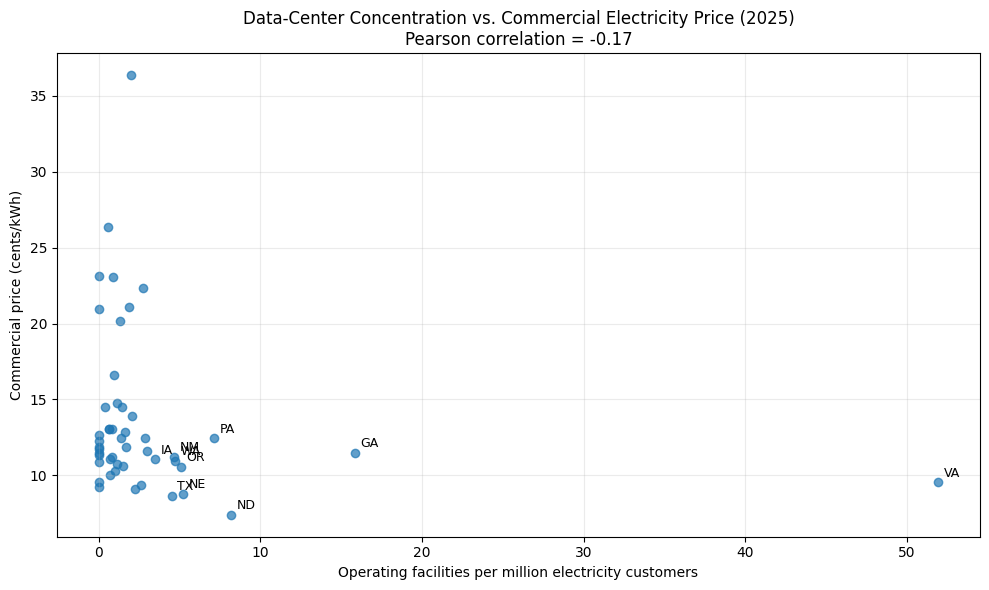

In [18]:
corr_commercial_price = scatter_with_labels(
    state_analysis, "operating_facilities_per_million_customers", "price_Commercial",
    "Data-Center Concentration vs. Commercial Electricity Price (2025)",
    "Operating facilities per million electricity customers", "Commercial price (cents/kWh)"
)

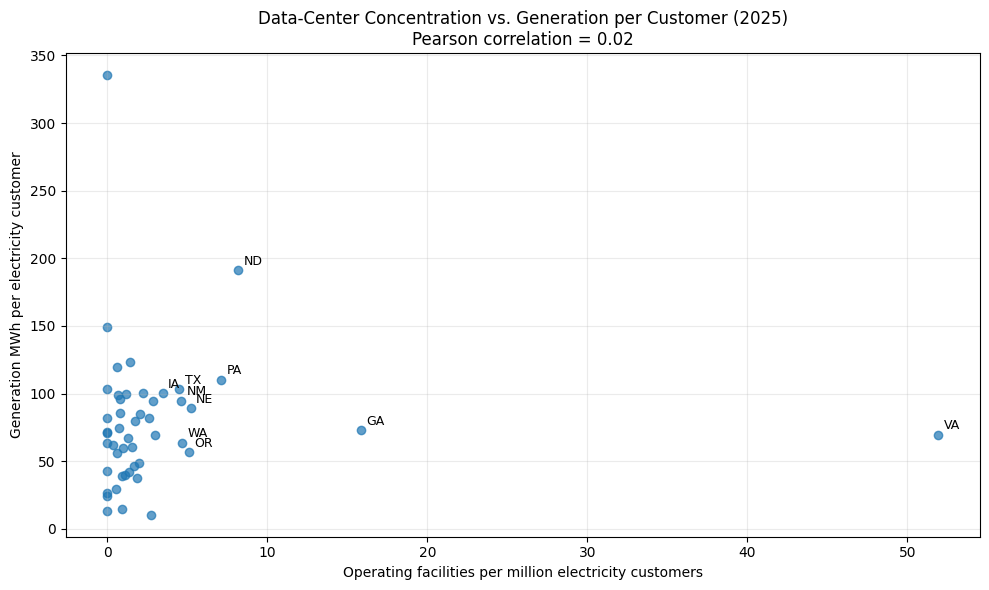

In [19]:
corr_generation_per_customer = scatter_with_labels(
    state_analysis, "operating_facilities_per_million_customers", "generation_mwh_per_customer",
    "Data-Center Concentration vs. Generation per Customer (2025)",
    "Operating facilities per million electricity customers", "Generation MWh per electricity customer"
)

## 8. Compare high- and low-data-center states

In [20]:
# Divide states with complete data into quartiles based on operating facilities per million customers.
comparison_cols = [
    "state", "operating_facilities_per_million_customers", "generation_mwh_per_customer",
    "price_Industrial", "price_Commercial", "price_Residential",
    "generation_2015_2025_pct_change", "customers_2015_2025_pct_change",
    "price_industrial_2015_2025_pct_change", "price_commercial_2015_2025_pct_change"
]
comparison = state_analysis[comparison_cols].dropna(subset=["operating_facilities_per_million_customers"]).copy()
comparison["dc_concentration_group"] = pd.qcut(
    comparison["operating_facilities_per_million_customers"],
    q=4,
    labels=["Lowest quartile", "Second quartile", "Third quartile", "Highest quartile"],
    duplicates="drop"
)

quartile_summary = comparison.groupby("dc_concentration_group", observed=True).agg(
    states=("state", "count"),
    median_dc_facilities_per_million=("operating_facilities_per_million_customers", "median"),
    median_generation_per_customer=("generation_mwh_per_customer", "median"),
    median_industrial_price=("price_Industrial", "median"),
    median_commercial_price=("price_Commercial", "median"),
    median_generation_growth_pct=("generation_2015_2025_pct_change", "median"),
    median_customer_growth_pct=("customers_2015_2025_pct_change", "median"),
    median_industrial_price_growth_pct=("price_industrial_2015_2025_pct_change", "median"),
).reset_index()
quartile_summary

,dc_concentration_group,states,median_dc_facilities_per_million,median_generation_per_customer,median_industrial_price,median_commercial_price,median_generation_growth_pct,median_customer_growth_pct,median_industrial_price_growth_pct
0,Lowest quartile,12,0.00,67.25,8.67,11.82,-21.81,9.47,25.24
1,Second quartile,12,0.82,67.22,8.68,13.04,-4.23,7.96,25.23
2,Third quartile,12,1.78,63.76,8.64,13.38,-18.85,8.20,28.89
3,Highest quartile,12,4.89,91.83,7.90,11.00,5.27,10.52,25.71


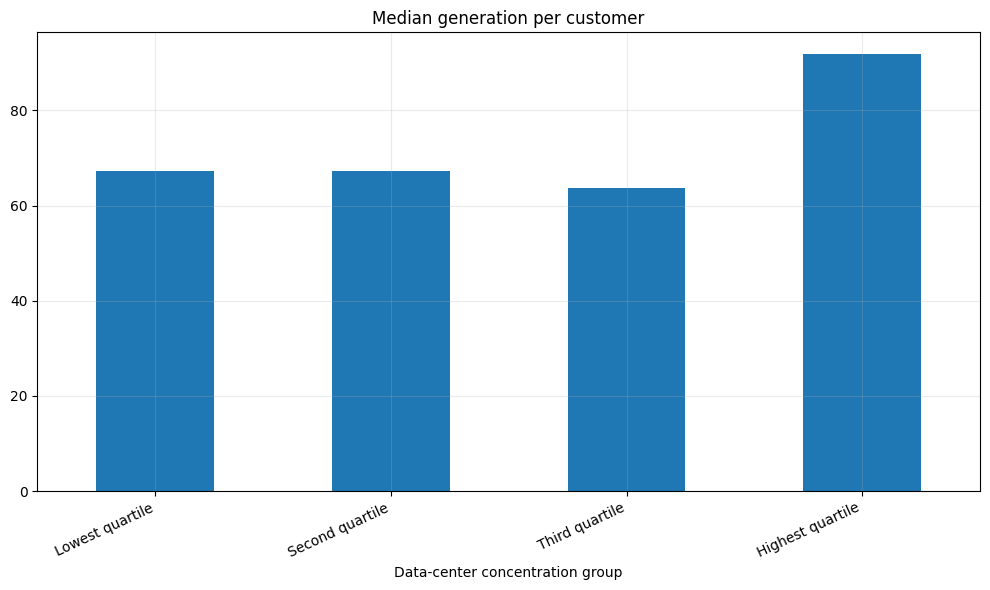

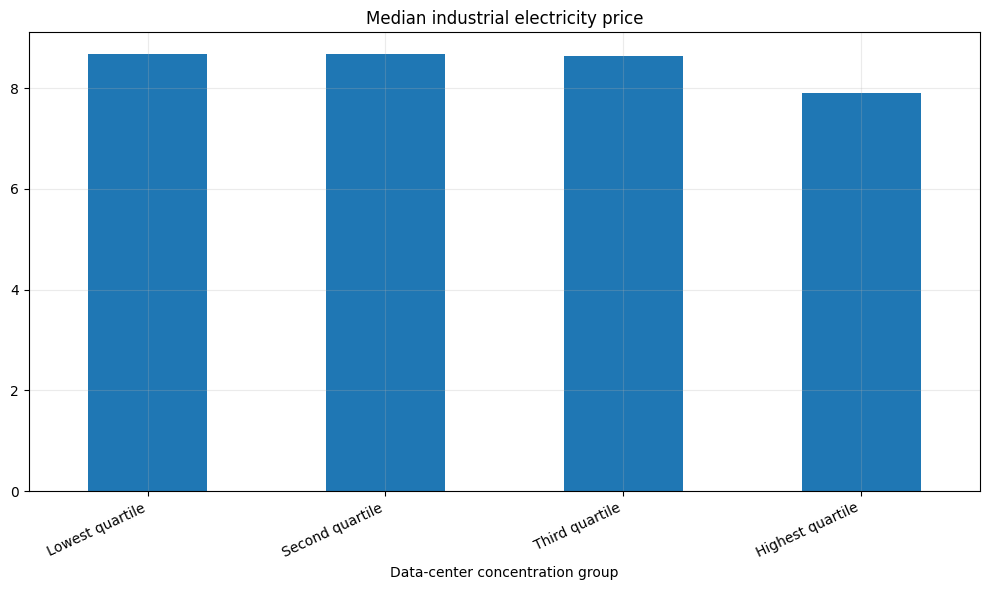

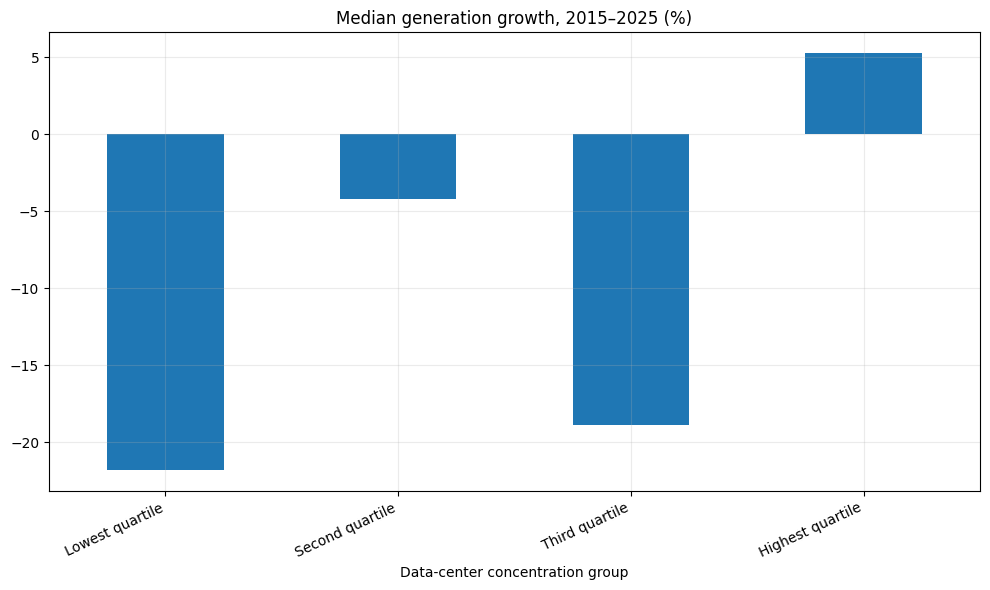

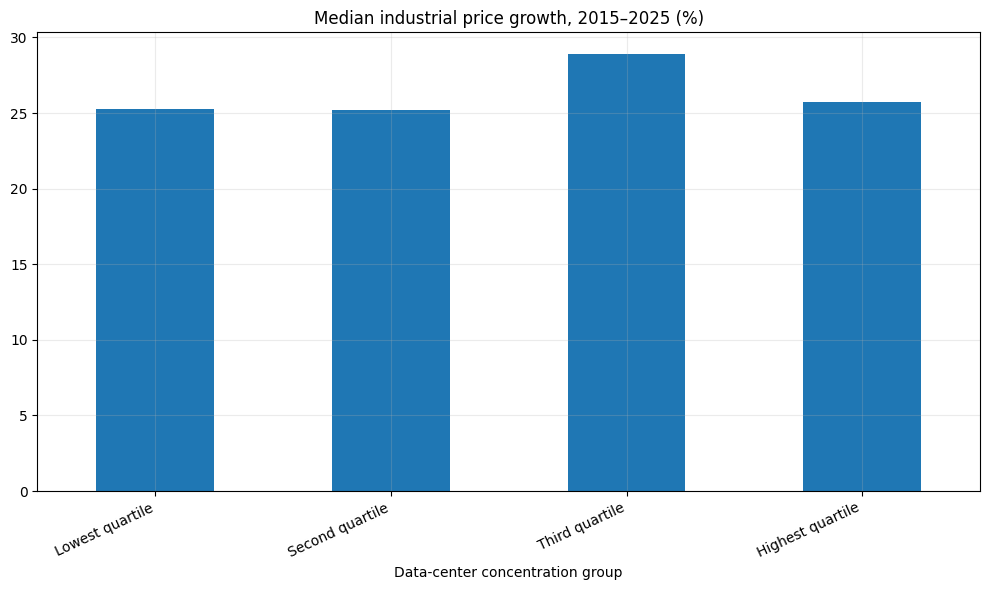

In [21]:
metrics = [
    ("median_generation_per_customer", "Median generation per customer"),
    ("median_industrial_price", "Median industrial electricity price"),
    ("median_generation_growth_pct", "Median generation growth, 2015–2025 (%)"),
    ("median_industrial_price_growth_pct", "Median industrial price growth, 2015–2025 (%)"),
]

for metric, title in metrics:
    ax = quartile_summary.set_index("dc_concentration_group")[metric].plot(kind="bar")
    ax.set_title(title)
    ax.set_xlabel("Data-center concentration group")
    ax.set_ylabel("")
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    plt.show()

## 9. Recent electricity trends in leading data-center states

In [22]:
# Select leading states using operating-facility count.
top_dc_states = state_analysis.nlargest(8, "operating_facilities")["state"].tolist()
top_dc_states

['VA', 'GA', 'TX', 'PA', 'WA', 'OH', 'NY', 'OR']

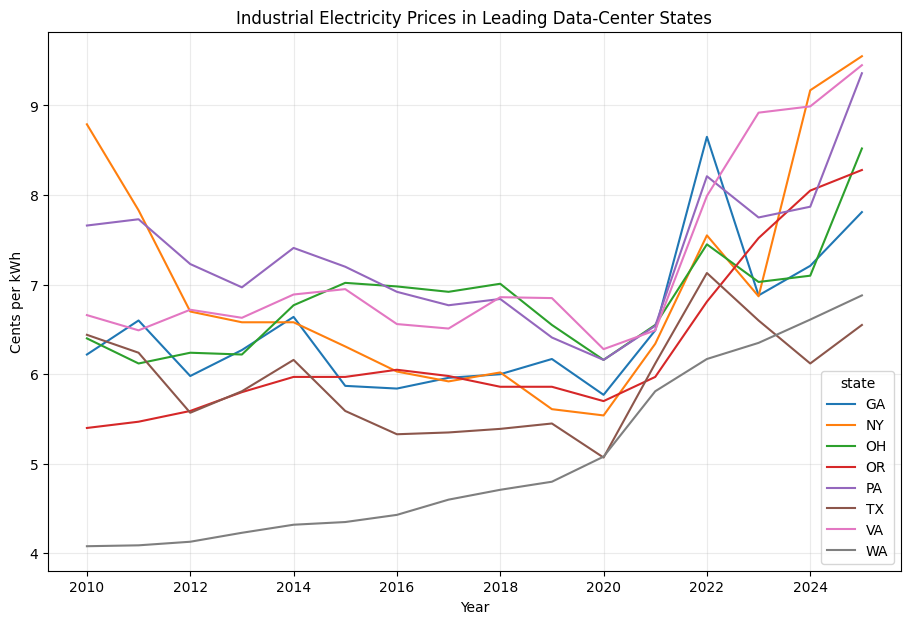

In [23]:
# Annual industrial price trends.
trend_price = state_prices[
    (state_prices["state"].isin(top_dc_states)) &
    (state_prices["sector"] == "Industrial") &
    (state_prices["year"].between(2010, LATEST_FULL_YEAR))
]

pivot_price = trend_price.pivot(index="year", columns="state", values="price_cents_kwh")
ax = pivot_price.plot(figsize=(11, 7))
ax.set_title("Industrial Electricity Prices in Leading Data-Center States")
ax.set_xlabel("Year")
ax.set_ylabel("Cents per kWh")

plt.show()

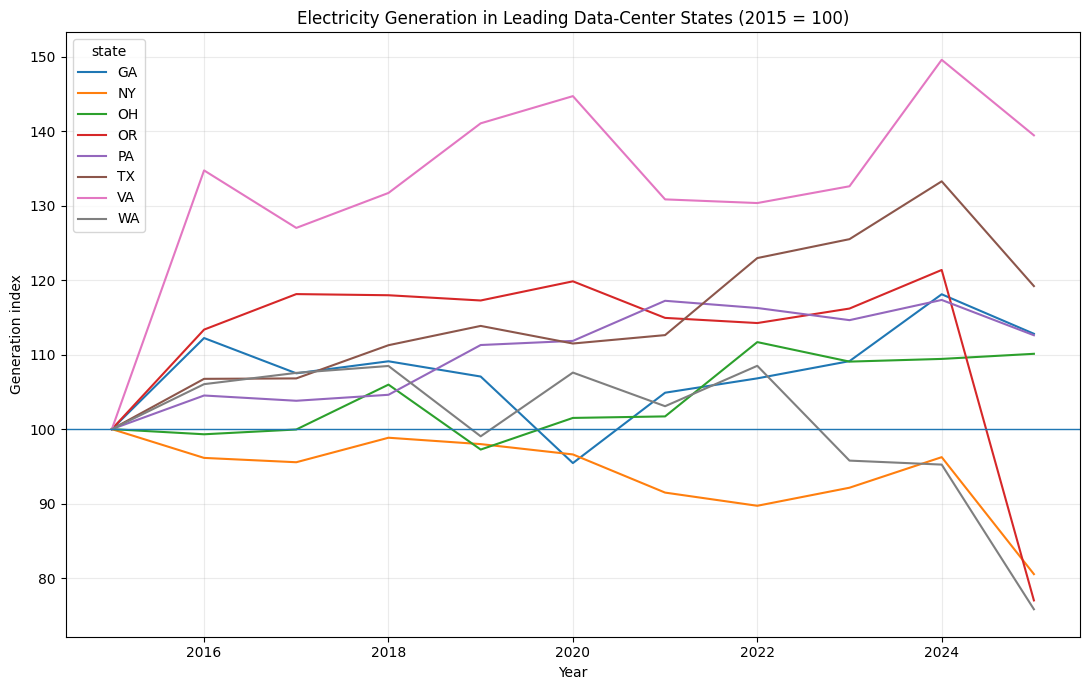

In [24]:
# Annual generation trends, indexed to 2015 = 100 for comparability across states.
trend_gen = state_generation[
    state_generation["state"].isin(top_dc_states) &
    state_generation["year"].between(BASE_YEAR, LATEST_FULL_YEAR)
]
pivot_gen = trend_gen.pivot(index="year", columns="state", values="generation_mwh")
indexed_gen = pivot_gen.divide(pivot_gen.loc[BASE_YEAR]).multiply(100)
ax = indexed_gen.plot(figsize=(11, 7))
ax.axhline(100, linewidth=1)
ax.set_title("Electricity Generation in Leading Data-Center States (2015 = 100)")
ax.set_xlabel("Year")
ax.set_ylabel("Generation index")
plt.tight_layout()
plt.show()

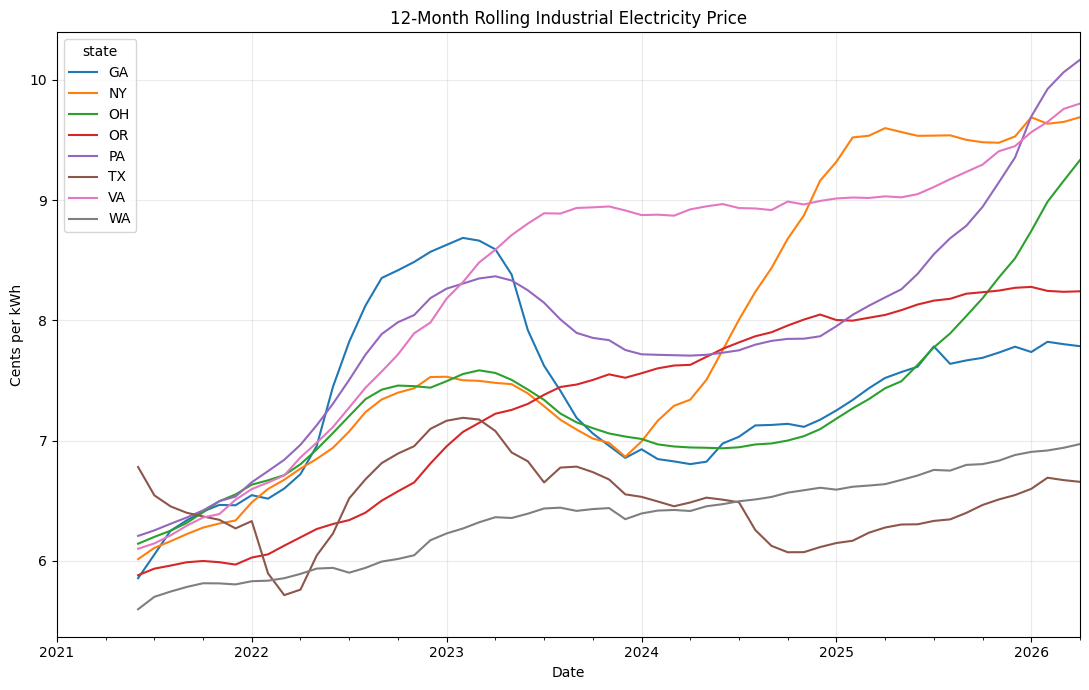

In [25]:
# Monthly industrial prices make recent volatility and seasonality visible.
monthly_industrial = price_m_long[
    (price_m_long["sector"] == "Industrial") &
    (price_m_long["state"].isin(top_dc_states)) &
    (price_m_long["date"] >= "2021-01-01")
]
monthly_pivot = monthly_industrial.pivot(index="date", columns="state", values="price_cents_kwh")
ax = monthly_pivot.rolling(12, min_periods=6).mean().plot(figsize=(11, 7))
ax.set_title("12-Month Rolling Industrial Electricity Price")
ax.set_xlabel("Date")
ax.set_ylabel("Cents per kWh")
plt.tight_layout()
plt.show()

## 10. Pipeline pressure and potential future infrastructure demand

In [26]:
# States where proposed/approved projects may add the most pressure.
pipeline_pressure = state_analysis[[
    "state", "operating_facilities", "pipeline_facilities", "operating_reported_mw",
    "pipeline_reported_mw", "generation_mwh", "customers", "price_Industrial"
]].copy()

pipeline_pressure["pipeline_to_operating_facility_ratio"] = (
    pipeline_pressure["pipeline_facilities"] / pipeline_pressure["operating_facilities"].replace(0, np.nan)
)
pipeline_pressure["reported_pipeline_mw_as_pct_generation_avg_mw"] = (
    100 * pipeline_pressure["pipeline_reported_mw"] /
    (pipeline_pressure["generation_mwh"] / 8760).replace(0, np.nan)
)

pipeline_pressure.sort_values("pipeline_facilities", ascending=False).head(15)

,state,operating_facilities,pipeline_facilities,operating_reported_mw,pipeline_reported_mw,generation_mwh,customers,price_Industrial,pipeline_to_operating_facility_ratio,reported_pipeline_mw_as_pct_generation_avg_mw
43,VA,215,263,"1,525.70","10,971.00","287,160,429.66","4,139,275.50",9.45,1.22,33.47
41,TX,66,137,"5,612.95","52,791.00","1,513,698,055.90","14,673,329.00",6.55,2.08,30.55
9,GA,87,85,"3,540.10","11,307.00","400,564,761.92","5,490,840.17",7.81,0.98,24.73
37,PA,45,51,437.10,"17,284.00","695,082,989.10","6,301,845.83",9.36,1.13,21.78
34,OH,17,43,"1,269.60","15,635.00","398,809,294.93","5,735,231.17",8.52,2.53,34.34
13,IL,5,27,90.35,"8,528.00","516,026,574.78","6,033,458.00",10.14,5.40,14.48
23,MO,5,25,0.00,"3,680.00","199,443,916.90","3,288,848.67",8.38,5.00,16.16
14,IN,7,24,"2,204.40","9,733.00","289,686,406.52","3,398,459.25",8.89,3.43,29.43
3,AZ,10,20,568.00,"6,446.00","332,616,913.62","3,519,509.75",8.10,2.00,16.98
4,CA,9,19,146.00,"1,844.00","471,117,226.80","16,134,692.67",21.62,2.11,3.43


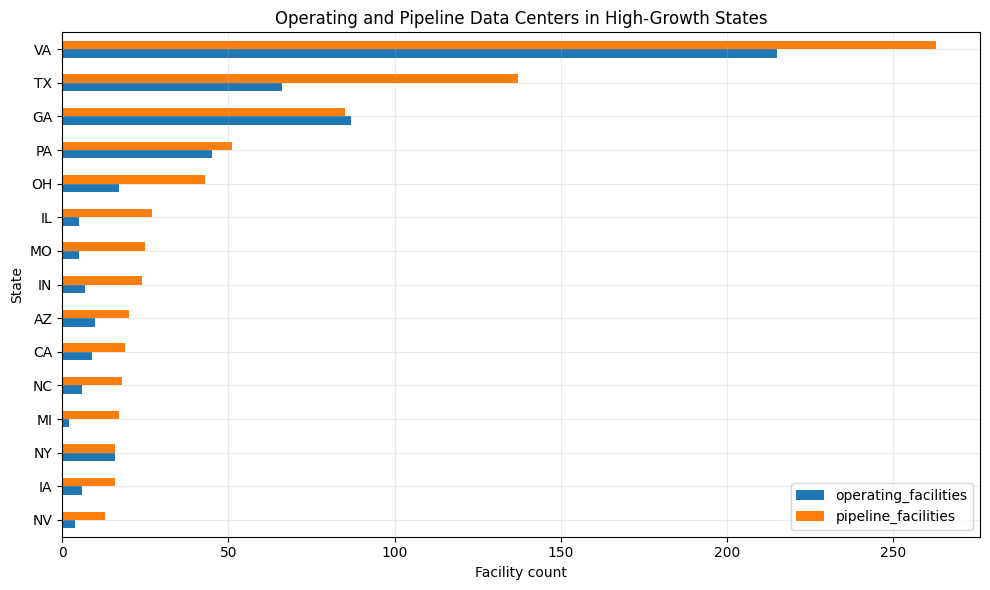

In [27]:
top_pipeline = pipeline_pressure.nlargest(15, "pipeline_facilities").sort_values("pipeline_facilities")
ax = top_pipeline.set_index("state")[["operating_facilities", "pipeline_facilities"]].plot(kind="barh")
ax.set_title("Operating and Pipeline Data Centers in High-Growth States")
ax.set_xlabel("Facility count")
ax.set_ylabel("State")
plt.tight_layout()
plt.show()

### Interpreting the pipeline-pressure metric

`reported_pipeline_mw_as_pct_generation_avg_mw` compares reported data-center pipeline MW with the state's average annual generation rate (`annual MWh / 8,760`). This is only a rough scale comparison because:

- not all facilities report MW,
- nameplate/requested data-center MW is not the same as continuously realized demand,
- generation is not identical to available local grid capacity,
- interstate power flows are not represented, and
- transmission and distribution constraints can occur even where statewide generation is large.

## 11. Correlation summary

In [28]:
correlation_vars = [
    "total_facilities", "operating_facilities", "pipeline_facilities",
    "operating_facilities_per_million_customers", "reported_total_mw",
    "generation_mwh", "generation_mwh_per_customer",
    "price_Industrial", "price_Commercial", "price_Residential",
    "generation_2015_2025_pct_change", "customers_2015_2025_pct_change",
    "price_industrial_2015_2025_pct_change", "price_commercial_2015_2025_pct_change"
]

corr = state_analysis[correlation_vars].corr()
focus = corr.loc[
    ["operating_facilities", "operating_facilities_per_million_customers", "reported_total_mw"],
    ["generation_mwh", "generation_mwh_per_customer", "price_Industrial", "price_Commercial",
     "generation_2015_2025_pct_change", "price_industrial_2015_2025_pct_change"]
]
focus

,generation_mwh,generation_mwh_per_customer,price_Industrial,price_Commercial,generation_2015_2025_pct_change,price_industrial_2015_2025_pct_change
operating_facilities,0.33,-0.01,-0.09,-0.16,0.36,0.09
operating_facilities_per_million_customers,0.11,0.02,-0.07,-0.17,0.31,0.02
reported_total_mw,0.78,0.22,-0.21,-0.24,0.32,-0.05


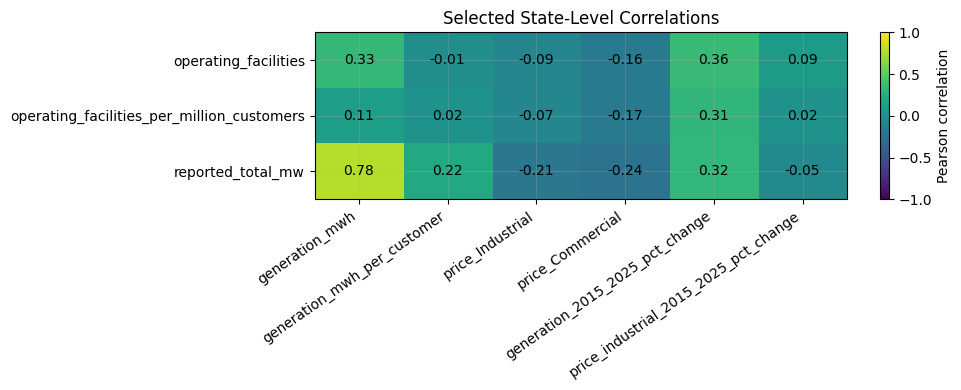

In [29]:
fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(focus.values, aspect="auto", vmin=-1, vmax=1)
ax.set_xticks(range(len(focus.columns)))
ax.set_xticklabels(focus.columns, rotation=35, ha="right")
ax.set_yticks(range(len(focus.index)))
ax.set_yticklabels(focus.index)
for i in range(focus.shape[0]):
    for j in range(focus.shape[1]):
        value = focus.iloc[i, j]
        ax.text(j, i, f"{value:.2f}" if pd.notna(value) else "NA", ha="center", va="center")
ax.set_title("Selected State-Level Correlations")
fig.colorbar(im, ax=ax, label="Pearson correlation")
plt.tight_layout()
plt.show()

## 12. Data-quality sensitivity: counts versus reported MW

In [30]:
# Check whether conclusions change when using facility counts rather than incomplete MW totals.
sensitivity = state_analysis[[
    "state", "total_facilities", "operating_facilities", "reported_total_mw",
    "mw_reporting_rate", "price_Industrial", "generation_mwh_per_customer"
]].copy()

sensitivity.sort_values("reported_total_mw", ascending=False).head(15)

,state,total_facilities,operating_facilities,reported_total_mw,mw_reporting_rate,price_Industrial,generation_mwh_per_customer
41,TX,199,66,"57,211.95",0.48,6.55,103.16
37,PA,103,45,"19,109.10",0.39,9.36,110.30
43,VA,459,215,"18,273.70",0.09,9.45,69.37
34,OH,63,17,"17,381.60",0.54,8.52,69.54
9,GA,178,87,"16,725.10",0.53,7.81,72.95
42,UT,11,1,"13,230.00",0.73,8.43,74.48
14,IN,41,7,"12,241.40",0.29,8.89,85.24
47,WY,6,0,"11,500.00",0.50,8.66,335.42
31,NM,9,5,"10,940.00",0.44,5.90,94.59
46,WV,12,0,"9,353.00",0.58,8.11,148.91


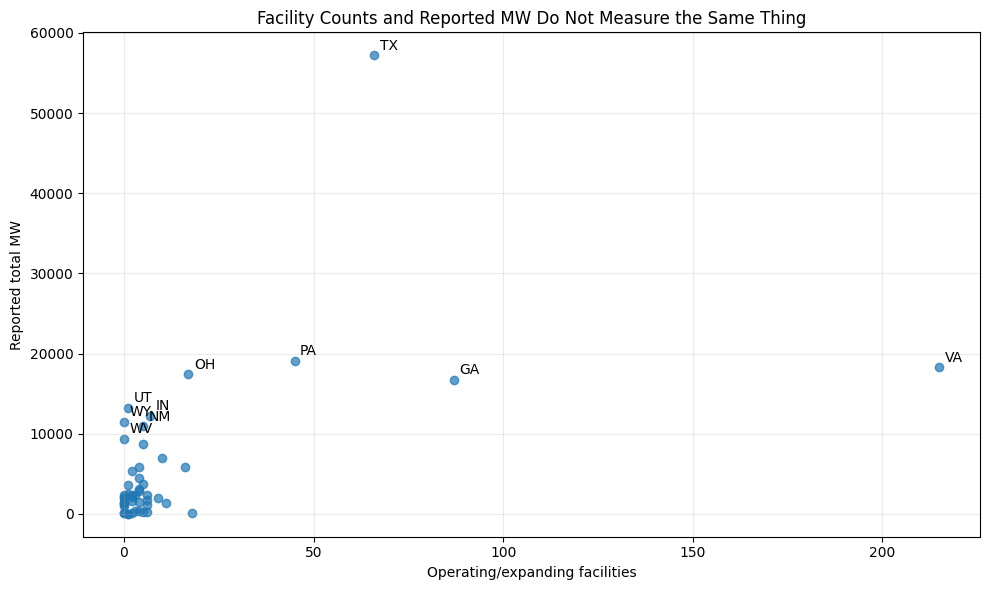

In [31]:
fig, ax = plt.subplots(figsize=(10, 6))
plot_data = sensitivity.dropna(subset=["operating_facilities", "reported_total_mw"])
ax.scatter(plot_data["operating_facilities"], plot_data["reported_total_mw"], alpha=0.7)
for _, row in plot_data.nlargest(10, "reported_total_mw").iterrows():
    ax.annotate(row["state"], (row["operating_facilities"], row["reported_total_mw"]),
                xytext=(4, 4), textcoords="offset points")
ax.set_title("Facility Counts and Reported MW Do Not Measure the Same Thing")
ax.set_xlabel("Operating/expanding facilities")
ax.set_ylabel("Reported total MW")
plt.tight_layout()
plt.show()

## 13. Conclusions

Use the outputs above to answer the research question cautiously:

1. **Data centers are geographically concentrated.** A relatively small set of states contains a large share of operating and proposed facilities, so infrastructure pressure is unlikely to be evenly distributed.
2. **High data-center concentration can coexist with high generation, but statewide generation alone does not establish local adequacy.** A state can generate substantial electricity while still facing transmission, substation, or distribution constraints near a cluster.
3. **Electricity prices should not be interpreted as a direct data-center effect.** State prices also reflect fuel mix, regulation, weather, transmission, taxes, market design, and many other factors.
4. **The project pipeline is a useful warning indicator.** States with many proposed or under-construction facilities may require capacity additions, transmission upgrades, new substations, or demand-management arrangements before the load is fully realized.
5. **The current evidence is descriptive rather than causal.** Any association in this notebook identifies where deeper investigation is warranted; it does not prove that data centers caused price or generation changes.

### Strongest defensible answer from these data

Data centers appear most likely to affect local power infrastructure where **operating facilities are already clustered and the development pipeline is large relative to the existing customer and generation base**. The effect is better interpreted as **potential system pressure and need for grid investment** than as a simple statewide increase in electricity price.

## 14. Recommended next steps for a stronger study

A more direct answer would merge these data with:

- county or utility service-territory electricity demand,
- utility integrated resource plans and load forecasts,
- interconnection-queue records,
- transmission and substation upgrade filings,
- utility capital expenditures and rate cases,
- outage and reliability metrics such as SAIDI/SAIFI,
- facility opening dates and actual metered load,
- county-level controls for population, income, climate, industrial activity, and fuel mix.

With reliable opening dates, a **difference-in-differences** or event-study design could compare infrastructure outcomes before and after major data-center openings against similar areas without openings.

## 15. Export analysis-ready tables

In [32]:
OUTPUT_DIR = Path("analysis_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

state_analysis.to_csv(OUTPUT_DIR / "state_data_center_power_analysis.csv", index=False)
quartile_summary.to_csv(OUTPUT_DIR / "data_center_concentration_quartile_summary.csv", index=False)
pipeline_pressure.to_csv(OUTPUT_DIR / "pipeline_pressure_summary.csv", index=False)

print("Saved:")
for f in OUTPUT_DIR.glob("*.csv"):
    print(" -", f)

Saved:
 - analysis_outputs/data_center_concentration_quartile_summary.csv
 - analysis_outputs/pipeline_pressure_summary.csv
 - analysis_outputs/state_data_center_power_analysis.csv
